---
# Title, summary, and page position.
linktitle: Practica Machine Learning
summary: Ejercicios de Machine Learning con Scikit-Learn - Soluciones
weight: 61
authors: ["joserzapata"]

# Page metadata.
title: Practica Machine Learning con Scikit-Learn - Soluciones
date: "2026-02-13T00:00:00Z"
lastmod: 2026-02-13
type: book  # Do not modify
---

## Curso Python para Ciencia de datos
#### Por Jose R. Zapata - https://joserzapata.github.io/

[![Invítame a un Café](https://img.buymeacoffee.com/button-api/?text=Invítame+a+un+Café&emoji=&slug=joserzapata&button_colour=328cc1&font_colour=ffffff&font_family=Comic&outline_colour=000000&coffee_colour=FFDD00)](https://www.buymeacoffee.com/joserzapata)

<div class="alert alert-success">

<b>NOTA:</b> Realizar primero los ejercicios y luego revisar las soluciones propuestas.

En este ejercicio práctico se aplicarán los conceptos de Machine Learning con Scikit-Learn vistos en el capítulo anterior:

- Pipelines de transformación
- Validación cruzada (Cross-Validation)
- Búsqueda de hiperparámetros (RandomizedSearchCV)
- Evaluación del modelo final
- Guardar y cargar modelos

</div>

## Descripción del Problema

Usaremos el dataset [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) que contiene características fisicoquímicas de vinos tintos portugueses. El objetivo es predecir la **calidad del vino** (clasificación binaria: bueno o malo) a partir de sus propiedades químicas.

Las características del dataset son:
- `fixed acidity` - acidez fija
- `volatile acidity` - acidez volátil
- `citric acid` - ácido cítrico
- `residual sugar` - azúcar residual
- `chlorides` - cloruros
- `free sulfur dioxide` - dióxido de azufre libre
- `total sulfur dioxide` - dióxido de azufre total
- `density` - densidad
- `pH` - pH
- `sulphates` - sulfatos
- `alcohol` - alcohol
- `quality` - calidad (variable objetivo, valor entre 3 y 8)

Transformaremos la variable `quality` en una variable binaria: **1** (bueno, quality >= 7) y **0** (malo, quality < 7).

---
## Ejercicio 1: Importar librerías

**Importe las siguientes librerías: `pandas`, `sklearn` , `matplotlib` e imprima las versiones de pandas y sklearn.**

In [8]:
# Copie el código aca
import pandas as pd
print(f"Pandas version: {pd.__version__}")
import sklearn
print(f"Sklearn version: {sklearn.__version__}")



Pandas version: 2.3.3
Sklearn version: 1.8.0


---
## Ejercicio 2: Cargar y explorar los datos

**Cargue el dataset de vinos tintos desde la siguiente URL y explore los datos.**

URL: `https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv`

**Nota:** El separador del archivo CSV es `;` (punto y coma).

Realice las siguientes exploraciones:
1. Muestre la información del DataFrame (`.info()`)
2. Muestre las primeras 5 filas
3. Muestre la descripción estadística

In [9]:
# Copie el código aca
import io
import requests
url_data = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
response = requests.get(url_data)
response.raise_for_status()

columnas = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

wine_df = pd.read_csv(io.StringIO(response.text),
                      header=0,
                      names=columnas,
                      na_values='?',
                      sep=';')
wine_df.info()
print(wine_df.sample(5))

wine_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1175            6.5              0.61        

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


---
## Ejercicio 3: Verificar valores nulos y duplicados

**Verifique si hay valores nulos en el dataset y cuántos datos duplicados existen. Si hay duplicados, elimínelos.**

In [10]:
# Copie el código aca
print("Valores nulos por columna:")
print(wine_df.isna().sum())
print(f"\nTotal de valores nulos: {wine_df.isna().sum().sum()}")

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores nulos: 0


In [12]:
# Verificar y eliminar duplicados
print(f"Filas antes de eliminar duplicados: {len(wine_df)}")
print(f"Filas duplicadas: {wine_df.duplicated().sum()}")
wine_df = wine_df.drop_duplicates()
print(f"Filas después de eliminar duplicados: {len(wine_df)}")

Filas antes de eliminar duplicados: 1359
Filas duplicadas: 0
Filas después de eliminar duplicados: 1359


In [ ]:
# Verificar valores nulos


Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores nulos: 0


In [ ]:
# Verificar y eliminar duplicados


Filas antes de eliminar duplicados: 1599
Filas duplicadas: 240
Filas después de eliminar duplicados: 1359


---
## Ejercicio 4: Crear la variable objetivo binaria

**Cree una nueva columna llamada `good_quality` que sea 1 si `quality >= 7` y 0 en caso contrario. Luego elimine la columna `quality` original.**

**Verifique la distribución de clases de la nueva variable objetivo. ¿Hay desbalance de clases?**

In [13]:
# Copie el código aca

# Crear variable objetivo binaria
wine_df['good_quality'] = (wine_df['quality'] >= 7).astype(int)

# Eliminar la columna quality original
wine_df = wine_df.drop(columns=['quality'])

# Verificar distribución de clases
print("Distribución de clases:")
print(wine_df['good_quality'].value_counts())
print(f"\nProporción de clase positiva: {wine_df['good_quality'].mean() * 100:.2f}%")

Distribución de clases:
good_quality
0    1175
1     184
Name: count, dtype: int64

Proporción de clase positiva: 13.54%


In [ ]:
# Crear variable objetivo binaria


# Eliminar la columna quality original

# Verificar distribución de clases


Distribución de clases:
good_quality
0    1175
1     184
Name: count, dtype: int64

Proporción de clase positiva: 13.54%


- Se puede observar que hay un **desbalance de clases**, ya que la clase positiva (vino bueno) representa una proporción mucho menor que la clase negativa.
- Por esta razón, usar **accuracy** como métrica no sería lo más adecuado. Es mejor usar **F1-Score** que balancea precision y recall.

---
## Ejercicio 5: Separar características y variable objetivo

**Separe el DataFrame en `X` (características) y `y` (variable objetivo `good_quality`).**

In [14]:
# Copie el código aca
X_features = wine_df.drop('good_quality', axis='columns')
Y_target = wine_df['good_quality']
print(f"X_features shape: {X_features.shape}")
print(f"Y_target shape: {Y_target.shape}")





X_features shape: (1359, 11)
Y_target shape: (1359,)


Forma de X: (1359, 11)
Forma de y: (1359,)

Columnas de X: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


---
## Ejercicio 6: Dividir datos en entrenamiento y test

**Divida los datos en conjuntos de entrenamiento (80%) y test (20%) usando `train_test_split`.**

**Importante:** Use `stratify=y` para mantener la proporción de clases y `random_state=42` para reproducibilidad.

In [15]:
# Copie el código aca
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_features,
                                                    Y_target,
                                                    test_size=0.2,
                                                    random_state=42)
print(f"Datos de entrenamiento: {len(x_train)} filas")
print(f"Datos de test: {len(x_test)} filas")
print()
print(f"Proporción clase positiva en entrenamiento: {y_train.mean() * 100:.2f}%")
print(f"Proporción clase positiva en test: {y_test.mean() * 100:.2f}%")

Datos de entrenamiento: 1087 filas
Datos de test: 272 filas

Proporción clase positiva en entrenamiento: 13.80%
Proporción clase positiva en test: 12.50%


Datos de entrenamiento: 1087 filas
Datos de test: 272 filas

Proporción clase positiva en entrenamiento: 13.52%
Proporción clase positiva en test: 13.60%


- Se puede verificar que la proporción de clases se mantiene similar en ambos conjuntos gracias al parámetro `stratify`.

---
## Ejercicio 7: Crear un Pipeline de preprocesamiento y modelo

**Cree un Pipeline que incluya los siguientes pasos:**

1. **StandardScaler** - para estandarizar las características
2. **RandomForestClassifier** - como modelo de clasificación

**Visualice el pipeline usando `set_config(display="diagram")`.**

Documentación:
- [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [19]:
# Copie el código aca
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(random_state=42))
    ]
)
set_config(display='diagram')
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', RandomForestClassifier(random_state=42))])

---
## Ejercicio 8: Evaluar el modelo con Validación Cruzada

**Evalúe el pipeline usando validación cruzada con 10 segmentos (folds).**

Use `StratifiedKFold` en lugar de `KFold` para mantener la proporción de clases en cada fold (importante cuando hay desbalance de clases).

Use la métrica **F1-Score** (`scoring='f1'`) ya que hay desbalance de clases.

**Imprima el resultado promedio y la desviación estándar.**

Documentación:
- [StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
- [cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)

In [27]:
# Copie el código aca
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)
scores = cross_validate(pipeline, x_train, y_train, cv=cv, scoring='f1')

f1_scores = scores['test_score']
print(f"F1-Score por fold: {f1_scores}")
print(f"F1-Score Promedio: {f1_scores.mean():.4f}")
print(f"F1-Score STD: {f1_scores.std():.4f}")

F1-Score por fold: [0.38095238 0.69230769 0.45454545 0.4        0.5625     0.2
 0.2        0.5        0.38461538 0.17391304]
F1-Score Promedio: 0.3949
F1-Score STD: 0.1601


F1-Score por fold: [0.58333333 0.36363636 0.45454545 0.27272727 0.60869565 0.5
 0.10526316 0.5        0.3        0.33333333]
F1-Score Promedio: 0.4022
F1-Score STD: 0.1480


---
## Ejercicio 9: Comparar múltiples modelos con Cross-Validation

**Compare al menos 3 modelos diferentes usando validación cruzada con la misma métrica (F1-Score) y el mismo esquema de folds.**

Modelos sugeridos:
1. `RandomForestClassifier`
2. `GradientBoostingClassifier`
3. `LogisticRegression`

**Cree un pipeline para cada modelo (con StandardScaler) y compare los resultados.**

Documentación:
- [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)
- [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [ ]:
# Copie el código aca

Definir los pipelines para random forest


In [32]:
# Copie el código aca
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(random_state=42))
    ]
)
set_config(display='diagram')
pipeline_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', RandomForestClassifier(random_state=42))])

Definir los pipelines para gradient boosting

In [33]:
# Copie el código aca
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import set_config

pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', GradientBoostingClassifier(random_state=42))
    ])
pipeline_gb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', GradientBoostingClassifier(random_state=42))])

Definir los pipelines para logistic regression

In [34]:
# Copie el código aca
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import set_config

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(random_state=42))
    ])
pipeline_lr


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

Evaluar cada modelo con cross-validation

In [43]:
# Copie el código aca
cv = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

scores_rf = cross_validate(pipeline_rf, x_train, y_train, cv=cv, scoring='f1')
scores_gb = cross_validate(pipeline_gb, x_train, y_train, cv=cv, scoring='f1')
scores_lr = cross_validate(pipeline_lr, x_train, y_train, cv=cv, scoring='f1')

modelos = [
    ('Random Forest', pipeline_rf),
    ('Gradient Boosting', pipeline_gb),
    ('Logistic Regression', pipeline_lr)
]
results = []

for nombre, pipe_modelo in modelos:
    scores = cross_validate(pipe_modelo, x_train, y_train, cv=cv, scoring='f1')
    f1_mean = scores['test_score'].mean()
    f1_std = scores['test_score'].std()
    print(f"{nombre:25} -> F1-Score: {f1_mean:.4f} ± {f1_std:.4f}")
    results.append({'Modelo': nombre, 'F1-Score': scores})



Random Forest             -> F1-Score: 0.3949 ± 0.1601
Gradient Boosting         -> F1-Score: 0.3912 ± 0.1587
Logistic Regression       -> F1-Score: 0.3656 ± 0.1319


Random Forest             -> F1-Score: 0.4022 ± 0.1480
Gradient Boosting         -> F1-Score: 0.4513 ± 0.1745
Logistic Regression       -> F1-Score: 0.3787 ± 0.1165


Crear una visualizacion de boxplot de los resultados de los modelos

<Figure size 800x500 with 0 Axes>

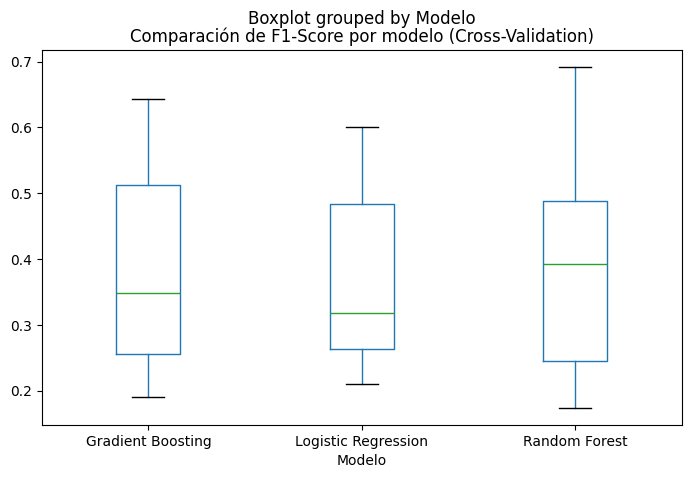

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

results = []
for nombre, pipe_modelo in modelos:
    scores = cross_validate(pipe_modelo, x_train, y_train, cv=cv, scoring='f1')
    for f1 in scores['test_score']:
        results.append({'Modelo': nombre, 'F1-Score': f1})

df_results = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
df_results.boxplot(column='F1-Score', by='Modelo', figsize=(8, 5))
# sns.boxplot(data=df_results, x='Modelo', y='F1-Score')
plt.grid(False)
plt.title('Comparación de F1-Score por modelo (Cross-Validation)')
plt.show()

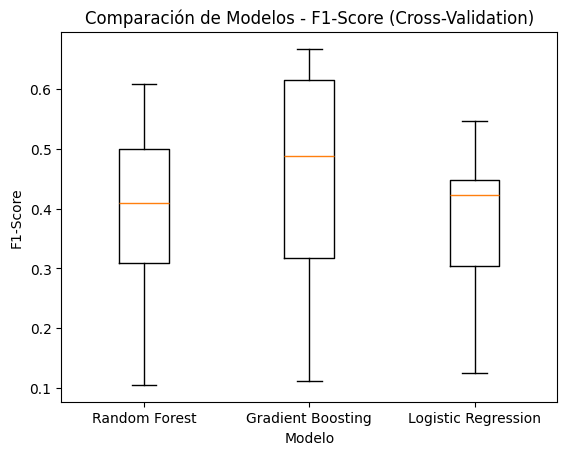

---
## Ejercicio 10: Búsqueda de Hiperparámetros con RandomizedSearchCV

**Tome el mejor modelo del ejercicio anterior y realice una búsqueda de hiperparámetros usando `RandomizedSearchCV`.**

`RandomizedSearchCV` es más eficiente que `GridSearchCV` cuando el espacio de hiperparámetros es grande, ya que prueba combinaciones aleatorias en lugar de todas las posibles.

**Para RandomForestClassifier, defina los siguientes rangos de hiperparámetros:**

```python
param_distributions = {
    "modelo__n_estimators": [50, 100, 200, 300, 500],
    "modelo__max_depth": [3, 5, 10, 15, 20, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__max_features": ["sqrt", "log2", None],
}
```

Use `n_iter=50` para probar 50 combinaciones aleatorias, `scoring='f1'` y `cv=skfold`.

Documentación: [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)

In [55]:
# Copie el código aca
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "modelo__n_estimators": [50, 100, 200, 300, 500],
    "modelo__max_depth": [3, 5, 10, 15, 20, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__max_features": ["sqrt", "log2", None],
}

random_search = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)
random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modelo__max_depth': [3, 5, ...], 'modelo__max_features': ['sqrt', 'log2', ...], 'modelo__min_samples_leaf': [1, 2, ...], 'modelo__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('modelo',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'modelo__max_depth': [3, 5, 10, 15, 20,
                                                              None],
                                        'modelo__max_features': ['sqrt', 'log2',
                                                                 None],
                                        'modelo__min_samples_leaf': [1, 2, 4],
                                        'modelo__min_samples_split': [2, 5, 10],
                                        'modelo__n_estimators': [50, 100, 200,
                                                                 300, 500]},
                   random_state=42, scoring='f1')

---
## Ejercicio 11: Analizar los resultados de la búsqueda de hiperparámetros

**Imprima los mejores hiperparámetros encontrados, el mejor F1-Score de cross-validation y su desviación estándar.**

**Además, muestre los 5 mejores resultados de la búsqueda en un DataFrame ordenado por el score.**

In [ ]:
# Copie el código aca
print('Mejores hiperparámetros encontrados:')
print(f'modelo__n_estimators: {random_search.best_params_["modelo__n_estimators"]}')
print(f'modelo__max_depth: {random_search.best_params_["modelo__max_depth"]}')
print(f'modelo__min_samples_split: {random_search.best_params_["modelo__min_samples_split"]}')
print(f'modelo__min_samples_leaf: {random_search.best_params_["modelo__min_samples_leaf"]}')
print(f'modelo__max_features: {random_search.best_params_["modelo__max_features"]}')
print(f'Mejor F1-Score de cross-validation: {random_search.best_score_:.4f}')
print(f'Desviación estándar del mejor F1-Score: {random_search.cv_results_["std_test_score"][0]:.4f}')


Mejores hiperparámetros encontrados:
modelo__n_estimators: 200
modelo__max_depth: 20
modelo__min_samples_split: 2
modelo__min_samples_leaf: 1
modelo__max_features: sqrt
Mejor F1-Score de cross-validation: 0.4094
Desviación estándar del mejor F1-Score: 0.1428


In [60]:
df_results = pd.DataFrame(random_search.cv_results_)
df_top5 = df_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score').head(5)
df_top5

,params,mean_test_score,std_test_score,rank_test_score
48,"{'modelo__n_estimators': 200, 'modelo__min_sam...",0.409423,0.151312,1
4,"{'modelo__n_estimators': 300, 'modelo__min_sam...",0.397041,0.146730,2
37,"{'modelo__n_estimators': 100, 'modelo__min_sam...",0.388020,0.128509,3
13,"{'modelo__n_estimators': 100, 'modelo__min_sam...",0.387020,0.129613,4
32,"{'modelo__n_estimators': 100, 'modelo__min_sam...",0.387020,0.129613,4


Mejores hiperparámetros encontrados:
  modelo__n_estimators: 200
  modelo__min_samples_split: 2
  modelo__min_samples_leaf: 1
  modelo__max_features: sqrt
  modelo__max_depth: 20

Mejor F1-Score CV: 0.4168
STD del mejor resultado: 0.1716


,params,mean_test_score,std_test_score,rank_test_score
48,"{'modelo__n_estimators': 200, 'modelo__min_sam...",0.416835,0.171640,1
18,"{'modelo__n_estimators': 300, 'modelo__min_sam...",0.407582,0.163016,2
37,"{'modelo__n_estimators': 100, 'modelo__min_sam...",0.405417,0.155120,3
15,"{'modelo__n_estimators': 100, 'modelo__min_sam...",0.404692,0.154009,4
47,"{'modelo__n_estimators': 100, 'modelo__min_sam...",0.404692,0.154009,4


---
## Ejercicio 12: Evaluar el modelo final con datos de Test

**Configure el pipeline con los mejores hiperparámetros, entrénelo con todos los datos de entrenamiento y evalúe con los datos de test.**

**Calcule las siguientes métricas en los datos de test:**
- Accuracy
- Precision
- Recall
- F1-Score

**Además, muestre el reporte de clasificación completo usando `classification_report`.**

Documentación: [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

In [62]:
# Copie el código aca
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Best model is already fitted on full training data (refit=True by default)
best_model = random_search.best_estimator_
y_pred = best_model.predict(x_test)

# Metrics
print("Métricas en datos de Test:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")


Métricas en datos de Test:
  Accuracy:  0.9044
  Precision: 0.7222
  Recall:    0.3824
  F1-Score:  0.5000


Métricas en datos de Test:
  Accuracy:  0.8934
  Precision: 0.7222
  Recall:    0.3514
  F1-Score:  0.4727


Crear un Reporte de clasificación con el método classification_report

In [63]:
# Copie el código aca
# Classification report (optional: target_names for class labels)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Malo', 'Bueno']))


Reporte de Clasificación:
              precision    recall  f1-score   support

        Malo       0.92      0.98      0.95       238
       Bueno       0.72      0.38      0.50        34

    accuracy                           0.90       272
   macro avg       0.82      0.68      0.72       272
weighted avg       0.89      0.90      0.89       272




Reporte de Clasificación:
              precision    recall  f1-score   support

        Malo       0.91      0.98      0.94       235
       Bueno       0.72      0.35      0.47        37

    accuracy                           0.89       272
   macro avg       0.81      0.67      0.71       272
weighted avg       0.88      0.89      0.88       272



---
## Ejercicio 13: Matriz de Confusión

**Visualice la matriz de confusión del modelo usando `ConfusionMatrixDisplay`.**

Documentación: [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)

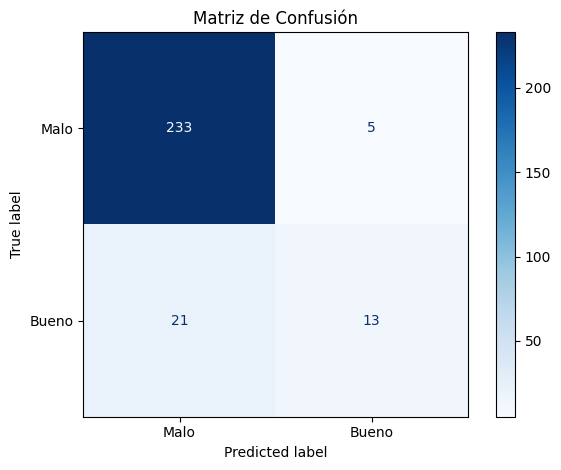

In [67]:
# Copie el código aca
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Malo', 'Bueno'], cmap='Blues')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

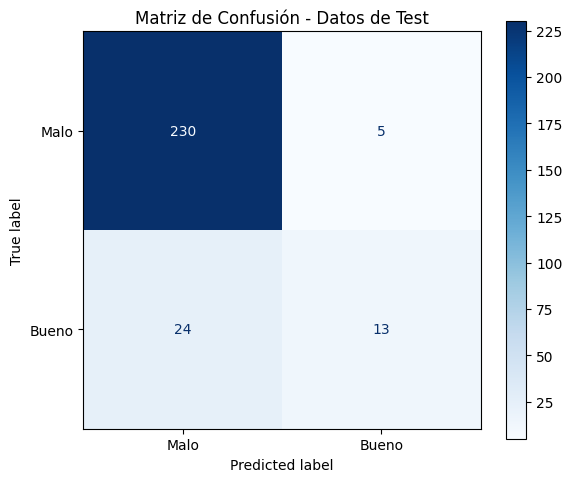

---
## Ejercicio 14: Pipeline con ColumnTransformer (Ejercicio Avanzado)

**Cree un pipeline más complejo que aplique diferentes transformaciones a diferentes columnas usando `ColumnTransformer`.**

Suponga que las primeras 7 columnas (`fixed acidity` hasta `total sulfur dioxide`) son características que necesitan estandarización con `StandardScaler`, y las últimas 4 columnas (`density` hasta `alcohol`) necesitan escalamiento con `MinMaxScaler`.

**Pasos:**
1. Defina las listas de columnas para cada tipo de transformación
2. Cree un `ColumnTransformer` con los transformadores apropiados
3. Cree un Pipeline completo con el `ColumnTransformer` y un `GradientBoostingClassifier`
4. Evalúe con cross-validation

Documentación:
- [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)
- [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

In [68]:
# Copie el código aca
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_validate

# 1. Column lists
columnas_standard = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
                     'chlorides', 'free sulfur dioxide', 'total sulfur dioxide']
columnas_minmax = ['density', 'pH', 'sulphates', 'alcohol']

# 2. ColumnTransformer
preprocessor = ColumnTransformer([
    ('standard', StandardScaler(), columnas_standard),
    ('minmax', MinMaxScaler(), columnas_minmax)
])

# 3. Full pipeline
pipeline_ct = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', GradientBoostingClassifier(random_state=42))
])

pipeline_ct

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standard', ...), ('minmax', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('standard', StandardScaler(),
                                                  ['fixed acidity',
                                                   'volatile acidity',
                                                   'citric acid',
                                                   'residual sugar',
                                                   'chlorides',
                                                   'free sulfur dioxide',
                                                   'total sulfur dioxide']),
                                                 ('minmax', MinMaxScaler(),
                                                  ['density', 'pH', 'sulphates',
                                                   'alcohol'])])),
                ('modelo', GradientBoostingClassifier(random_state=42))])

Evaluar con cross-validation

In [69]:
# Copie el código aca
scores = cross_validate(pipeline_ct, x_train, y_train, cv=cv, scoring='f1')
print(f"F1-Score Promedio: {scores['test_score'].mean():.4f}")
print(f"F1-Score STD: {scores['test_score'].std():.4f}")

F1-Score Promedio: 0.3912
F1-Score STD: 0.1587


F1-Score Promedio: 0.4513
F1-Score STD: 0.1745


Crear un Boxplot de los resultados del F1-Score de los 10 folds

/var/folders/b5/xrc2pq9n3rg5x0nj4rh88wr80000gn/T/ipykernel_92340/2445663174.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(fold_scores, labels=['F1 -score '])


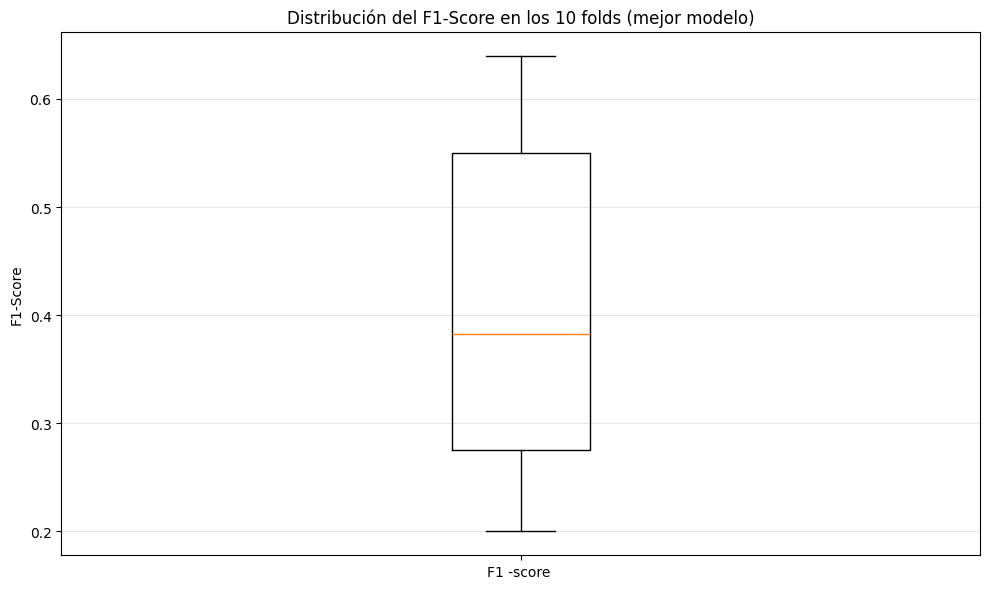

In [71]:
# Copie el código aca
import matplotlib.pyplot as plt
import numpy as np

# Get F1 scores for the 10 folds of the best model
best_idx = random_search.best_index_
fold_scores = [random_search.cv_results_[f'split{i}_test_score'][best_idx] for i in range(10)]

# Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(fold_scores, labels=['F1 -score '])
plt.ylabel('F1-Score')
plt.title('Distribución del F1-Score en los 10 folds (mejor modelo)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

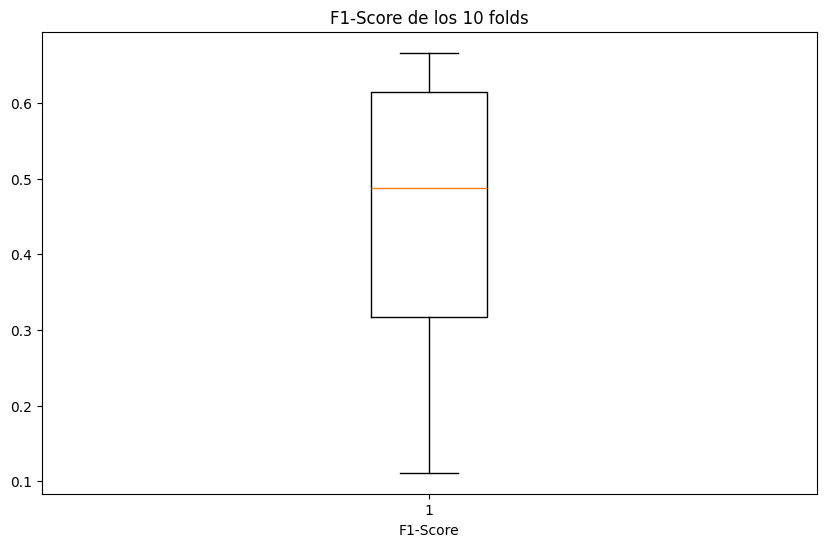

---
## Ejercicio 15: RandomizedSearchCV con el Pipeline avanzado

**Realice una búsqueda de hiperparámetros con `RandomizedSearchCV` para el pipeline con `ColumnTransformer` y `GradientBoostingClassifier`.**

**Defina los siguientes rangos de hiperparámetros:**

```python
param_distributions_gb = {
    "modelo__n_estimators": [50, 100, 200, 300],
    "modelo__max_depth": [3, 5, 7, 10],
    "modelo__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__subsample": [0.8, 0.9, 1.0],
}
```

Use `n_iter=50`, `scoring='f1'` y `cv=skfold`.

In [ ]:
# Copie el código aca
# Copie el código aca
from sklearn.model_selection import RandomizedSearchCV

skfold = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

param_distributions_gb = {
    "modelo__n_estimators": [50, 100, 200, 300],
    "modelo__max_depth": [3, 5, 7, 10],
    "modelo__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__subsample": [0.8, 0.9, 1.0],
}
random_search_gb = RandomizedSearchCV(
    pipeline_ct,
    param_distributions=param_distributions_gb,
    n_iter=50,
    cv=skfold,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search_gb.fit(x_train, y_train)
random_search_gb


Mejores hiperparámetros encontrados:
modelo__n_estimators: 200
modelo__max_depth: 3
modelo__min_samples_split: 2
modelo__min_samples_leaf: 2
Mejor F1-Score de cross-validation: 0.4676
Desviación estándar del mejor F1-Score: 0.2220


In [75]:
print('Mejores hiperparámetros encontrados:')
print(f'modelo__subsample: {random_search_gb.best_params_["modelo__subsample"]}')
print(f'modelo__n_estimators: {random_search_gb.best_params_["modelo__n_estimators"]}')
print(f'modelo__min_samples_split: {random_search_gb.best_params_["modelo__min_samples_split"]}')
print(f'modelo__min_samples_leaf: {random_search_gb.best_params_["modelo__min_samples_leaf"]}')
print(f'modelo__max_depth: {random_search_gb.best_params_["modelo__max_depth"]}')
print(f'modelo__learning_rate: {random_search_gb.best_params_["modelo__learning_rate"]}')

print(f'Mejor F1-Score de cross-validation: {random_search_gb.best_score_:.4f}')
print(f'Desviación estándar del mejor F1-Score: {random_search_gb.cv_results_["std_test_score"][0]:.4f}')

Mejores hiperparámetros encontrados:
modelo__subsample: 1.0
modelo__n_estimators: 200
modelo__min_samples_split: 2
modelo__min_samples_leaf: 2
modelo__max_depth: 3
modelo__learning_rate: 0.2
Mejor F1-Score de cross-validation: 0.4676
Desviación estándar del mejor F1-Score: 0.2220


Mejores hiperparámetros encontrados:
  modelo__subsample: 1.0
  modelo__n_estimators: 200
  modelo__min_samples_split: 2
  modelo__min_samples_leaf: 2
  modelo__max_depth: 3
  modelo__learning_rate: 0.2

Mejor F1-Score CV: 0.4681
STD del mejor resultado: 0.1643


---
## Ejercicio 16: Evaluación final del mejor modelo

**Entrene el mejor modelo (con los mejores hiperparámetros) con todos los datos de entrenamiento y evalúe con los datos de test.**

**Muestre las métricas y el reporte de clasificación.**

In [76]:
# Copie el código aca
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Best model from Ejercicio 15 (RandomizedSearchCV on advanced pipeline)
best_model_gb = random_search_gb.best_estimator_
y_pred_gb = best_model_gb.predict(x_test)

# Metrics
print("Métricas en datos de Test (Gradient Boosting optimizado):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_gb, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_gb, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_gb, zero_division=0):.4f}")

# Classification report
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_gb, target_names=['Malo', 'Bueno']))

Métricas en datos de Test (Gradient Boosting optimizado):
  Accuracy:  0.8971
  Precision: 0.6250
  Recall:    0.4412
  F1-Score:  0.5172

Reporte de Clasificación:
              precision    recall  f1-score   support

        Malo       0.92      0.96      0.94       238
       Bueno       0.62      0.44      0.52        34

    accuracy                           0.90       272
   macro avg       0.77      0.70      0.73       272
weighted avg       0.89      0.90      0.89       272



Métricas en datos de Test (Gradient Boosting optimizado):
  Accuracy:  0.8971
  Precision: 0.6957
  Recall:    0.4324
  F1-Score:  0.5333

Reporte de Clasificación:
              precision    recall  f1-score   support

        Malo       0.92      0.97      0.94       235
       Bueno       0.70      0.43      0.53        37

    accuracy                           0.90       272
   macro avg       0.81      0.70      0.74       272
weighted avg       0.89      0.90      0.89       272



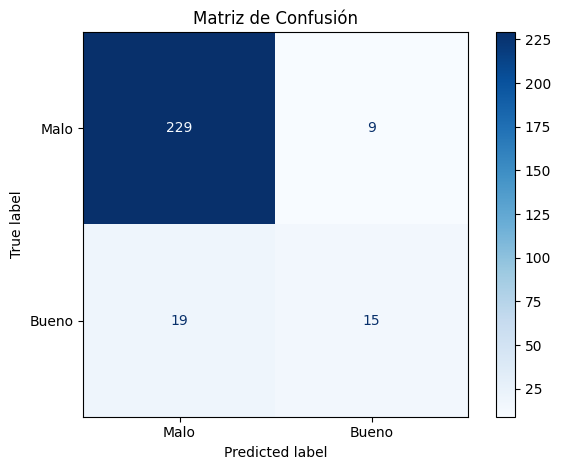

In [77]:
# Copie el código aca
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, display_labels=['Malo', 'Bueno'], cmap='Blues')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

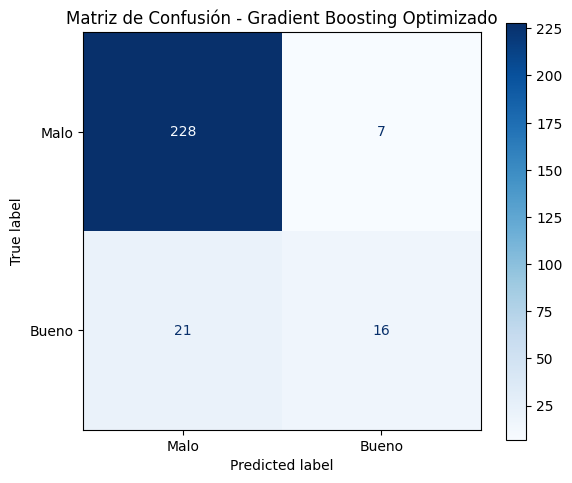

---
## Ejercicio 17: Entrenar modelo final y guardarlo

**Entrene el mejor modelo con TODOS los datos disponibles (entrenamiento + test) y guárdelo usando `joblib`.**

Esto se hace para aprovechar al máximo la información disponible antes de desplegar el modelo en producción.

Documentación: [Model Persistence](https://scikit-learn.org/stable/model_persistence.html)

In [78]:
# Copie el código aca

import joblib

# Best model from Ejercicio 15 (advanced pipeline with ColumnTransformer)
modelo_final = random_search_gb.best_estimator_

# Train on ALL data (train + test)
modelo_final.fit(X_features, Y_target)

# Optional: verify F1 on full data
y_pred_full = modelo_final.predict(X_features)
from sklearn.metrics import f1_score
print(f"F1-Score (todos los datos): {f1_score(Y_target, y_pred_full):.4f}")

# Save model
joblib.dump(modelo_final, 'pipeline_wine_quality.joblib')
print("\nModelo guardado exitosamente en 'pipeline_wine_quality.joblib'")

F1-Score (todos los datos): 0.9973

Modelo guardado exitosamente en 'pipeline_wine_quality.joblib'


F1-Score (todos los datos): 0.9973

Modelo guardado exitosamente en 'pipeline_wine_quality.joblib'


---
## Ejercicio 18: Cargar el modelo y hacer predicciones

**Cargue el modelo guardado y realice predicciones con nuevos datos.**

Use los siguientes datos de ejemplo para hacer predicciones:

```python
nuevos_datos = pd.DataFrame({
    "fixed acidity": [7.4, 11.2],
    "volatile acidity": [0.70, 0.28],
    "citric acid": [0.00, 0.56],
    "residual sugar": [1.9, 1.9],
    "chlorides": [0.076, 0.075],
    "free sulfur dioxide": [11.0, 17.0],
    "total sulfur dioxide": [34.0, 60.0],
    "density": [0.9978, 0.9980],
    "pH": [3.51, 3.16],
    "sulphates": [0.56, 0.58],
    "alcohol": [9.4, 9.8],
})
```

In [80]:
import joblib
import pandas as pd

# Load saved model
modelo_cargado = joblib.load('pipeline_wine_quality.joblib')

# Example data
nuevos_datos = pd.DataFrame({
    "fixed acidity": [7.4, 11.2],
    "volatile acidity": [0.70, 0.28],
    "citric acid": [0.00, 0.56],
    "residual sugar": [1.9, 1.9],
    "chlorides": [0.076, 0.075],
    "free sulfur dioxide": [11.0, 17.0],
    "total sulfur dioxide": [34.0, 60.0],
    "density": [0.9978, 0.9980],
    "pH": [3.51, 3.16],
    "sulphates": [0.56, 0.58],
    "alcohol": [9.4, 9.8],
})

# Predict
predicciones = modelo_cargado.predict(nuevos_datos)

# Display
print("Predicciones para nuevos datos:")
for i, pred in enumerate(predicciones, 1):
    etiqueta = "Bueno" if pred == 1 else "Malo"
    print(f"  Vino {i}: {pred} ({etiqueta})")

Predicciones para nuevos datos:
  Vino 1: 0 (Malo)
  Vino 2: 0 (Malo)


Predicciones para nuevos datos:
  Vino 1: 0 (Malo)
  Vino 2: 0 (Malo)


---
## Ejercicio 19 (Bono): Importancia de las características

**Extraiga la importancia de las características del mejor modelo y visualícelas en un gráfico de barras horizontal.**

**Tip:** Para acceder al modelo dentro del pipeline, use `pipeline.named_steps['modelo']` y luego `.feature_importances_`.

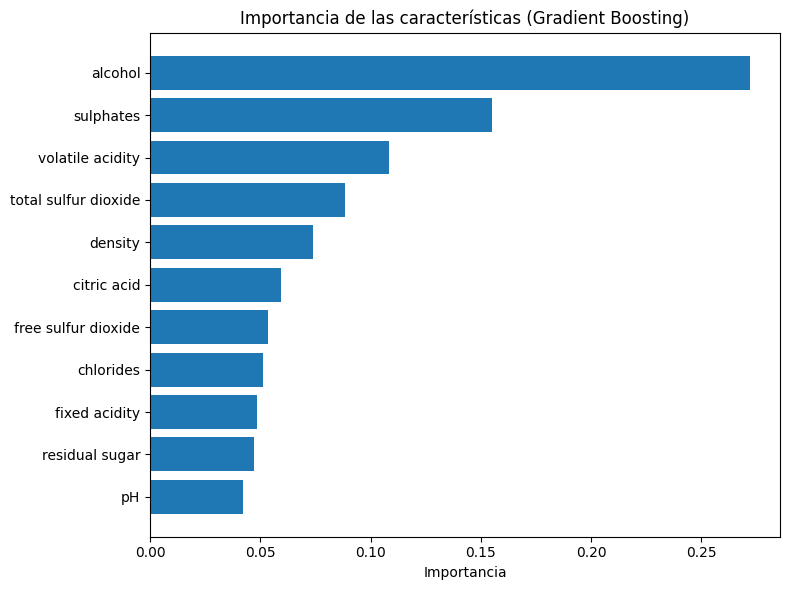

In [81]:
# Copie el código aca
import matplotlib.pyplot as plt
import numpy as np

# Use the final model (trained on all data, from Ejercicio 17)
# Or: modelo_final = random_search_gb.best_estimator_
modelo = modelo_final  # or modelo_cargado if loaded in Ejercicio 18

# Get model and feature importances
clf = modelo.named_steps['modelo']
importances = clf.feature_importances_

# Get feature names from the preprocessor (ColumnTransformer)
preprocessor = modelo.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

# Clean names: remove transformer prefix (e.g. "standard__fixed acidity" -> "fixed acidity")
feature_names_clean = [name.split('__')[-1] for name in feature_names]

# Sort by importance
indices = np.argsort(importances)

# Horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), [feature_names_clean[i] for i in indices])
plt.xlabel('Importancia')
plt.title('Importancia de las características (Gradient Boosting)')
plt.tight_layout()
plt.show()

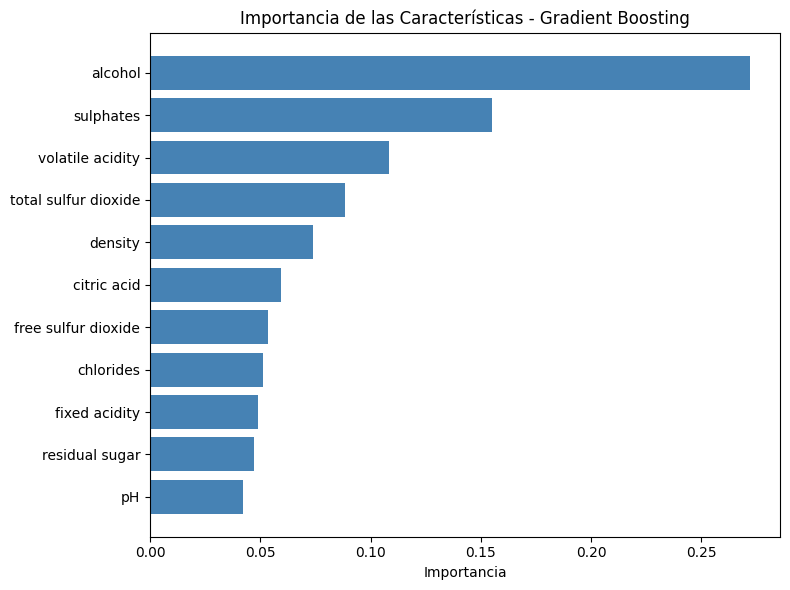

---
## Resumen

En esta práctica se aplicaron los siguientes conceptos de Machine Learning con Scikit-Learn:

1. **Exploración y preparación de datos:** carga, limpieza, eliminación de duplicados y creación de variable objetivo binaria
2. **Pipelines:** creación de pipelines simples y con `ColumnTransformer` para diferentes transformaciones por columna
3. **Validación cruzada:** uso de `StratifiedKFold` y `cross_validate` para evaluar modelos de forma robusta
4. **Comparación de modelos:** evaluación de múltiples algoritmos con la misma metodología
5. **Búsqueda de hiperparámetros:** uso de `RandomizedSearchCV` para encontrar la mejor configuración
6. **Evaluación final:** métricas de clasificación, reporte de clasificación y matriz de confusión
7. **Persistencia del modelo:** guardar y cargar el pipeline completo con `joblib`
8. **Importancia de características:** análisis de qué variables son más relevantes para el modelo

**Phd. Jose R. Zapata**
- [https://joserzapata.github.io/](https://joserzapata.github.io/)
- [https://www.linkedin.com/in/jose-ricardo-zapata-gonzalez/](https://www.linkedin.com/in/jose-ricardo-zapata-gonzalez/)